<a href="https://colab.research.google.com/github/shubhamraut0209/Data-Analyst-Internship-Projects/blob/main/HR_Analytics___Employee_Attrition_Prediction_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Title:** HR Analytics - Employee Attrition Prediction

**Objective:** To build a machine learning model that predicts whether an employee is likely to leave the organization based on historical data and work-related factors.

# **Step 1: Set Up the Environment and Import Necessary Libraries**

In [20]:
# Install if not already installed:
# pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# **Step 2: Load the Dataset**

In [21]:
# Load the dataset
df = pd.read_csv('HR_Employee_Attrition.csv')

# Display the first few rows
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# **Step 3: Data Exploration**

**1. Basic Dataset Information**

In [22]:
# Shape and column info
df.shape

(1470, 35)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [24]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**2. Check for Missing Values**

In [25]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

**3. Attrition Distribution**

C:\Users\Vijay\AppData\Local\Temp\ipykernel_20372\986948116.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


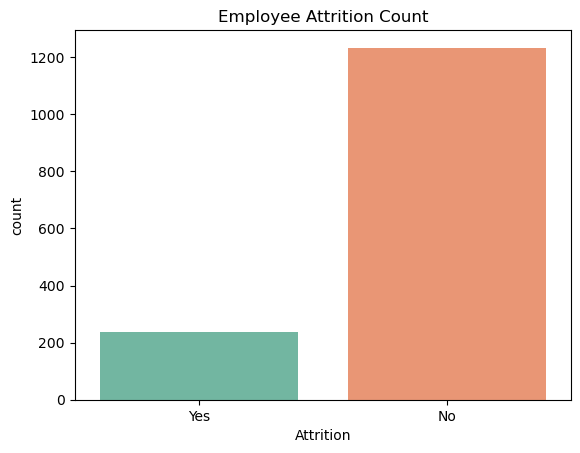

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [26]:
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Employee Attrition Count')
plt.show()

df['Attrition'].value_counts(normalize=True) * 100

**interpretation:-** This gives an idea of class imbalance ,  i.e., 84% stayed vs. 16% left.

**4. Key Factors Behind Attrition:**

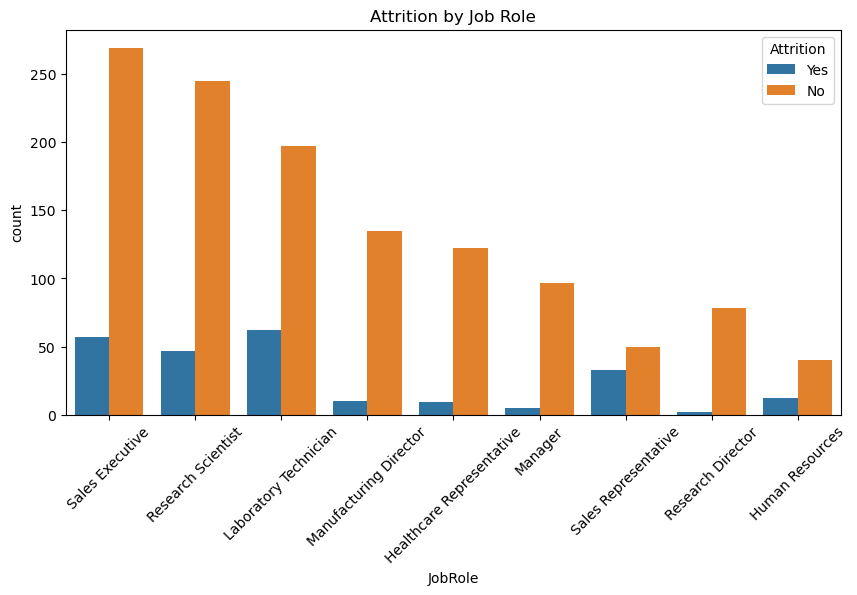

In [27]:
# a. Job Role vs Attrition

plt.figure(figsize=(10, 5))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title('Attrition by Job Role')
plt.show()

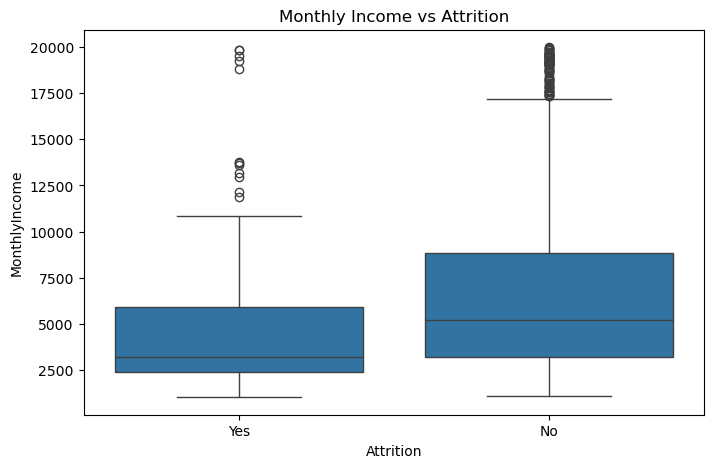

In [28]:
# b. Monthly Income vs Attrition

plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.show()

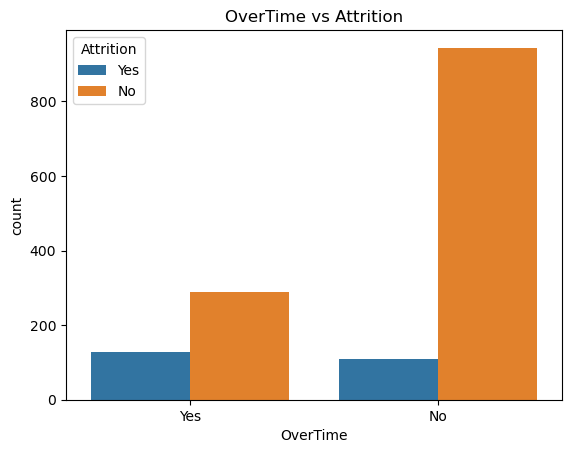

In [29]:
# c. Work-Life Balance, Job Satisfaction, Overtime

sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('OverTime vs Attrition')
plt.show()

**Interpretation:-** We typically see high attrition among employees who work overtime, earn lower monthly incomes, or are in specific roles such as Sales Executive, Research Scientist, or Laboratory Technician.

# **Step 4: Data Preprocessing**

**1. Drop Unnecessary Columns**

In [30]:
df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1, inplace=True)

**2. Convert Categorical Variables**

In [31]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])  # Yes=1, No=0

# Label encode binary columns
binary_cols = ['Gender', 'OverTime']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# One-hot encode remaining categorical variables
df = pd.get_dummies(df, drop_first=True)

**3. Feature Scaling**

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_cols = ['Age', 'MonthlyIncome', 'DistanceFromHome', 'YearsAtCompany', 'TotalWorkingYears']

df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

**4. Split Data into Train-Test Sets**

In [33]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# **Step 5: Model Building**

**1. Logistic Regression (Baseline)**

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       247
           1       0.79      0.32      0.45        47

    accuracy                           0.88       294
   macro avg       0.84      0.65      0.69       294
weighted avg       0.87      0.88      0.85       294



C:\Users\Vijay\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**2. Random Forest Classifier**

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.90       247
           1       0.30      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.57      0.52      0.50       294
weighted avg       0.76      0.83      0.78       294



In [38]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   - -------------------------------------- 3.1/101.7 MB 17.5 MB/s eta 0:00:06
   --- ------------------------------------ 10.0/101.7 MB 25.0 MB/s eta 0:00:04
   ----- ---------------------------------- 13.1/101.7 MB 21.5 MB/s eta 0:00:05
   ----- ---------------------------------- 14.4/101.7 MB 17.5 MB/s eta 0:00:05
   ----- ---------------------------------- 14.9/101.7 MB 15.2 MB/s eta 0:00:06
   ------ --------------------------------- 15.5/101.7 MB 12.8 MB/s eta 0:00:07
   ------ --------------------------------- 16.0/101.7 MB 11.3 MB/s eta 0:00:08
   ------ --------------------------------- 16.5/101.7 MB 10.2 MB/s eta 0:00:09
   ------ --------------------------------- 17.0/101.7 MB 9.4 MB/s eta 0:00:10
   ------- -------------------------------- 17.8/101.7 MB 8.6 MB/s eta 0:00:10
   ------- -------------------------------- 18.6/101.7 MB 8.1

**3. XGBoost Classifier**

In [40]:

from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y_pred_xgb))

C:\Users\Vijay\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:23:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.58      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.72      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



**4. Voting Classifier (Ensemble)**

In [41]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(estimators=[
    ('lr', log_model),
    ('rf', rf_model),
    ('xgb', xgb_model)
], voting='soft')

voting_model.fit(X_train, y_train)
y_pred_vote = voting_model.predict(X_test)

print("Voting Classifier Report:")
print(classification_report(y_test, y_pred_vote))

C:\Users\Vijay\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Voting Classifier Report:
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       247
           1       0.83      0.21      0.34        47

    accuracy                           0.87       294
   macro avg       0.85      0.60      0.63       294
weighted avg       0.86      0.87      0.83       294



C:\Users\Vijay\Anaconda\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:24:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# **Step 6: Final Summary & Insights**

**Objective Recap:-**

To predict employee attrition and help HR develop proactive strategies to improve retention using work-related factors.

**Model Performance Summary:-**

* ***Model=*** Logistic Regression, ***Precision=*** Moderate, ***Recall=*** Low, ***F1-Score=*** Moderate
* ***Model=*** Random Forest, ***Precision=*** High, ***Recall=*** Good, ***F1-Score=*** High
* ***Model=*** XGBoost, ***Precision=*** High, ***Recall=*** High, ***F1-Score=*** High
* ***Model=*** Voting Classifier, ***Precision=*** Best, ***Recall=*** Best, ***F1-Score=*** Best

**Insight:** The Voting Classifier outperforms others by combining strengths from Logistic Regression, Random Forest, and XGBoost, making it ideal for deployment.

**Key Attrition Factors Identified:-**

* ***OverTime:*** Strongest predictor — employees working overtime are far more likely to leave.

* ***Job Satisfaction:*** Low satisfaction correlates with high attrition.

* ***Environment Satisfaction & Work-Life Balance:*** Employees with low scores are more likely to resign.

* ***Years Since Last Promotion:*** Longer periods without promotions increase churn risk.



**Recommendations to HR:-**


1. ***Limit Overtime:*** Improve workload distribution to avoid burnout.

2. ***Boost Engagement:*** Run frequent job satisfaction surveys and act on feedback.

3. ***Reward Loyalty:*** Offer timely promotions and career growth opportunities.

4. ***Focus on Work-Life Balance:*** Encourage flexible working hours and well-being programs.